In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
# compute weight-class
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from argparse import Namespace
import numpy as np
import pandas as pd
from tqdm import tqdm, trange
from momentfm import MOMENTPipeline
import time
from datetime import timedelta
import matplotlib.pyplot as plt
import os
import torch.nn.functional as F
import gc
import copy
import seaborn as sns

from datetime import datetime, timedelta
import traceback
import subprocess
import re


/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [2]:
######################## GPU CHECKING AND SETUP ##############################

# To check what gpu running eun the command "nvidia-smi".
# This will show you the GPU and the memory usage, and what procces are running.

# Function to check if GPU is available and set it up
def print_gpu_info():
    """
    Print the GPU information if available.
    """
    # GPU handling
    print(torch.__version__)
    print(torch.version.cuda)
    torch.cuda.is_available()
    # Seeing that the GPU hase enough memory to run
    print(torch.cuda.empty_cache())  # Frees unused memory
    print(torch.cuda.memory_summary(device=None, abbreviated=False))  # Shows memory usage
    print(torch.cuda.ipc_collect())


# getting the GPU and checking if it is available and what gpu has the most memory
def get_least_used_gpu():
    """Find the GPU with the most available memory using nvidia-smi."""
    try:
        # Run nvidia-smi and get memory info
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=memory.free", "--format=csv,nounits,noheader"],
            stdout=subprocess.PIPE,
            text=True,
            check=True
        )
        
        # Parse output into a list of free memory values
        free_memory = [int(x) for x in result.stdout.strip().split("\n")]
        print(free_memory)
        
        # Find GPU with max free memory
        best_gpu = free_memory.index(max(free_memory))
        # Set it for PyTorch
        torch.cuda.set_device(best_gpu)
        print(f"Using GPU: {torch.cuda.current_device()} (GPU {best_gpu})")

        return best_gpu

    except Exception as e:
        print(f"Error getting GPU memory info: {e}")
        return 0  # Default to GPU 0 if there's an issue


In [3]:

# Get the best GPU with the most free memory
best_gpu = get_least_used_gpu()

# Set it for PyTorch
torch.cuda.set_device(best_gpu)
print(f"Using GPU: {torch.cuda.current_device()} (GPU {best_gpu})")

[18494, 19735, 18956]
Using GPU: 1 (GPU 1)
Using GPU: 1 (GPU 1)


In [4]:
####################### TIME SERIES FUNCTIONS ##############################

# Time series configuration Class
class TimeSeriesConfig:
    def __init__(self,
                 model_type='nst',
                 num_class=5,
                 seq_len=101,
                 num_features=1,
                 classes_names=['Google Doc', 'Google Drive', 'Google Music', 'Google Search', 'Youtube'],
                 dataset_name='genericQuicText',
                 small_window='unknown',
                 criterion_type = 'CrossEntropyLoss',
                 optimizer_type = 'Adam',
                 feature_name = 'TotalSize'
                ):
        
        # Common configurations for all models
        self.task_name = 'classification'
        self.seq_len = seq_len  # Your sequence length
        self.pred_len = 0   # Not used in classification
        self.label_len = 0  # Not used in classification
        
        # Input/Output dimensions
        self.enc_in = num_features      # Number of input features
        self.dec_in = 1      # Not used in classification
        self.c_out = 1       # Not used in classification
        self.num_class = num_class   # Number of classes
        
        # Training parameters
        self.dropout = 0.1
        self.embed = 'timeF'
        self.freq = 'h'
        self.batch_size = 128 #32#64 #512
        self.learning_rate = 1e-4 #1e-3
        self.num_epochs = 5 #5
        self.criterion_type = criterion_type #'CrossEntropyLoss' # 'CrossEntropyLoss','FocalLoss'
        self.optimizer_type = optimizer_type #'Adam' #'SGD','AdamW' ,'Adam'
        self.feature_name = feature_name #'TotalSize' # 'packetAmount'
        self.dataset_name=dataset_name
        self.small_window=small_window

        # Other configs
        self.use_gpu = True if torch.cuda.is_available() else False
        self.checkpoint_dir = f'checkpoints/{self.dataset_name}/{self.num_class}' # packets feature'
        self.classes_names = classes_names
        
        self.model_name = f'{model_type.lower()}_classifier'

        # Model specific configurations
        if model_type.lower() == 'moment':
            self._set_moment_config()
        else:
            raise ValueError(f"Unknown model type: {model_type}")
    
    def _set_moment_config(self):
        self.n_channels=1
        self.device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    def print_config(self):
        """Print all configurations"""
        print("\nModel Configuration:")
        print("-" * 50)
        for attr, value in self.__dict__.items():
            print(f"{attr}: {value}")
        print("-" * 50)

In [5]:
############### Model learing helpers #####################
class EarlyStopping:
    """
    Early stopping to stop training when validation loss doesn't improve,
    but only after learning rate has reached its minimum value.
    
    Args:
        scheduler (ReduceLROnPlateau): The learning rate scheduler
        patience (int): How many epochs to wait after last improvement
        delta (float): Minimum change to qualify as an improvement
        mode (str): 'min' for loss monitoring, 'max' for accuracy monitoring
        verbose (bool): If True, prints a message for each improvement
        restore_best_weights (bool): If True, restore model to best weights when stopped
    """
    def __init__(self, scheduler, patience=5, delta=0.001, mode='min', verbose=True, restore_best_weights=True):
        self.scheduler = scheduler
        self.patience = patience
        self.delta = delta
        self.mode = mode
        self.verbose = verbose
        self.restore_best_weights = restore_best_weights
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_weights = None
        
        # Set initial value depending on mode
        if self.mode == 'min':
            self.val_best = np.inf
        else:
            self.val_best = -np.inf
    
    def __call__(self, val_metric, model):
        # Check if learning rate has reached minimum
        current_lr = self.scheduler.get_lr()
        min_lr_reached = current_lr <= (self.scheduler.min_lr * 1.1)  # Allow slight margin
        
        if not min_lr_reached:
            if self.verbose:
                print(f'EarlyStopping: Current LR {current_lr:.2e} not yet at minimum {self.scheduler.min_lr:.2e}, not counting')
            return
        
        # If we're here, learning rate is at minimum, proceed with early stopping check
        if self.mode == 'min':
            score = -val_metric  # For minimization (e.g., loss)
        else:
            score = val_metric   # For maximization (e.g., accuracy)
            
        if self.best_score is None:
            # First epoch
            self.best_score = score
            self.save_checkpoint(val_metric, model)
        elif score <= self.best_score + self.delta:
            # No improvement or not enough improvement
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience} '
                      f'(LR at minimum: {current_lr:.2e})')
            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights and self.best_model_weights is not None:
                    if self.verbose:
                        print('Restoring model to best weights')
                    model.load_state_dict(self.best_model_weights)
        else:
            # Improvement
            self.best_score = score
            self.save_checkpoint(val_metric, model)
            self.counter = 0
            
    def save_checkpoint(self, val_metric, model):
        """Save model when validation metric improves."""
        if self.verbose:
            improved = 'decreased' if self.mode == 'min' else 'increased'
            print(f'Validation metric {improved} ({self.val_best:.6f} --> {val_metric:.6f}). Saving model.')
        self.val_best = val_metric
        self.best_model_weights = copy.deepcopy(model.state_dict())


class ReduceLROnPlateau:
    """
    Reduce learning rate when a metric has stopped improving.
    
    Args:
        optimizer (Optimizer): Optimizer whose learning rate will be reduced.
        mode (str): 'min' for loss monitoring, 'max' for accuracy monitoring.
        factor (float): Factor by which to reduce learning rate.
        patience (int): Number of epochs with no improvement after which LR will be reduced.
        min_lr (float): Lower bound on the learning rate.
        verbose (bool): If True, prints a message for each update.
        delta (float): Minimum change to qualify as an improvement.
    """
    def __init__(self, optimizer, mode='min', factor=0.1, patience=2, 
                 min_lr=1e-6, verbose=True, delta=0.001):
        self.optimizer = optimizer
        self.mode = mode
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.verbose = verbose
        self.delta = delta
        
        self.counter = 0
        self.best_score = None
        self.lr_at_minimum = False
        
        # Set initial value depending on mode
        if self.mode == 'min':
            self.val_best = np.inf
        else:
            self.val_best = -np.inf
    
    def step(self, metrics):
        """
        Reduce learning rate if metrics don't improve.
        
        Args:
            metrics (float): Evaluation metric to monitor.
        """
        if self.mode == 'min':
            score = -metrics  # For minimization (e.g., loss)
        else:
            score = metrics   # For maximization (e.g., accuracy)
            
        if self.best_score is None:
            # First epoch
            self.best_score = score
            self.val_best = metrics
        elif score <= self.best_score + self.delta:
            # No improvement or not enough improvement
            self.counter += 1
            if self.verbose:
                print(f'ReduceLROnPlateau counter: {self.counter} out of {self.patience}')
            
            if self.counter >= self.patience:
                # Reduce learning rate
                current_lr = self.get_lr()
                
                # Check if we can reduce further
                if current_lr <= (self.min_lr * 1.01):  # Allow small margin for floating point
                    if not self.lr_at_minimum:
                        if self.verbose:
                            print(f'Learning rate reached minimum: {current_lr:.2e}')
                        self.lr_at_minimum = True
                else:
                    # Reduce learning rate
                    new_lr = max(current_lr * self.factor, self.min_lr)
                    for param_group in self.optimizer.param_groups:
                        param_group['lr'] = new_lr
                        
                    if self.verbose:
                        print(f'Reducing learning rate from {current_lr:.6f} to {new_lr:.6f}')
                    
                    # Reset counter only if we actually reduced the learning rate
                    if new_lr < current_lr:
                        self.counter = 0
                        
                    # Check if we've reached minimum
                    if new_lr <= (self.min_lr * 1.01):
                        self.lr_at_minimum = True
                        if self.verbose:
                            print(f'Learning rate now at minimum: {new_lr:.2e}')
        else:
            # Improvement
            self.best_score = score
            self.val_best = metrics
            self.counter = 0
    
    def get_lr(self):
        """Get current learning rate."""
        return self.optimizer.param_groups[0]['lr']
    
    def is_at_minimum(self):
        """Check if learning rate is at minimum."""
        return self.lr_at_minimum
    

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, input, target):
        ce_loss = F.cross_entropy(input, target, reduction='none', weight=self.weight)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt)**self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss




In [6]:
# For weighted class
def get_class_weights(y_train, method='balanced'):
    """
    Calculate class weights to handle imbalanced datasets.
    
    Args:
        y_train: Training labels
        method: Method to compute weights ('balanced' or 'inverse')
    
    Returns:
        Class weights as a tensor
    """
    # Count samples per class
    class_counts = np.bincount(y_train)
    
    if method == 'balanced':
        # Compute balanced weights: n_samples / (n_classes * np.bincount(y))
        n_samples = len(y_train)
        n_classes = len(np.unique(y_train))
        weights = n_samples / (n_classes * class_counts)
    elif method == 'inverse':
        # Simple inverse weighting: 1 / count
        weights = 1. / class_counts
    else:
        # Compute using sklearn
        weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    
    print(f"Class distribution: {class_counts}")
    print(f"Class weights: {weights}")
    
    # Convert to tensor for use with PyTorch
    weights_tensor = torch.FloatTensor(weights)
    if torch.cuda.is_available():
        weights_tensor = weights_tensor.cuda()
    
    return weights_tensor

In [7]:
####################### Plotting Metrics ##############################
def dynamic_figsize(num_classes, base_size=1.0, max_size=20):
    """Dynamically adjust figure size based on the number of classes."""
    size = min(max(base_size * np.log1p(num_classes), 8), max_size)  # Log scaling
    return (size, size)

def plot_metrics(train_losses, val_losses, train_accs, val_accs, config):
    """
    Plot and save training metrics with comprehensive training details
    Only plots loss and accuracy (no recall, precision, or F1 curves)
    """
    save_dir = config.checkpoint_dir
    try:
        # Create directory if it doesn't exist
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
            print(f"Created directory: {save_dir}")
        
        print("\nPlotting Training Metrics...")
        
        # Create a figure with appropriate size
        plt.figure(figsize=(16, 10))
        
        # Create title with model details
        title_parts = [
            f"Dataset: {config.dataset_name}",
            f"Windows: {config.small_window}",
            f"Feature: {config.feature_name}",
            f"Model: {config.model_name}",
            f"Optimizer: {config.optimizer_type}",
            f"Loss: {config.criterion_type}",
            f"Epochs: {len(train_losses)}/{config.num_epochs}",
            f"Seq Len: {config.seq_len}",
            f"Initial LR: {config.learning_rate}"
        ]
        main_title = " | ".join(title_parts)
        
        # Add title to the figure
        plt.suptitle(main_title, fontsize=14, fontweight='bold', y=0.98)
        
        # Plot losses
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Training Loss', linewidth=2)
        plt.plot(val_losses, label='Validation Loss', linewidth=2)
        plt.title('Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        
        # Plot accuracies
        plt.subplot(1, 2, 2)
        plt.plot(train_accs, label='Training Accuracy', linewidth=2)
        plt.plot(val_accs, label='Validation Accuracy', linewidth=2)
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        
        # Adjust layout
        plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle
        
        # Add config details as text on the figure
        config_text = (
            f"Batch Size: {config.batch_size}\n"
            f"Classes: {config.num_class}\n"
            f"Features: {config.enc_in}\n"
            f"Final Train Acc: {train_accs[-1]:.2f}%\n"
            f"Final Val Acc: {val_accs[-1]:.2f}%\n"
            f"Best Train Acc: {max(train_accs):.2f}%\n"
            f"Best Val Acc: {max(val_accs):.2f}%"
        )
        
        # Add text box with config details
        plt.figtext(0.5, 0.01, config_text, ha="center", fontsize=10, 
                   bbox={"facecolor":"lightgray", "alpha":0.5, "pad":5})
        
        # Create a detailed filename
        filename = (
            f"{config.dataset_name}_"
            f"{config.small_window}_"
            f"{config.feature_name}_"
            f"{config.model_name}_"
            f"e{len(train_losses)}_"
            f"opt{config.optimizer_type}_"
            f"lr{config.learning_rate}_"
            f"loss{config.criterion_type}_"
            f"trainAcc{max(train_accs):.1f}_"
            f"valAcc{max(val_accs):.1f}.png"
        )
        
        # Save path with full directory
        save_path = os.path.join(save_dir, filename)
        print(f"Saving metrics plot to: {save_path}")
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print("Successfully saved metrics plot")
        
        # Display the plot
        plt.show()
        
        # Close the plot
        plt.close()
        
    except Exception as e:
        print(f"Error in plotting metrics: {str(e)}")
        import traceback
        traceback.print_exc()


In [8]:
def plot_confusion_matrix(y_true, y_pred, config):
    """Plot and save confusion matrix (both raw and percentage-normalized)."""
    save_dir = config.checkpoint_dir
    classes = config.classes_names

    try:
        # Ensure save directory exists
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
            print(f"Created directory: {save_dir}")

        print("\nCreating confusion matrices...")

        # Compute confusion matrices
        cm = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # Normalize row-wise
        cm_norm_percent = cm_norm * 100  # Convert to percentages

        def plot_and_save(cm, title, filename, normalize=False):
            """Helper function to plot and save a confusion matrix."""
            try:
                # plt.figure(figsize=(15, 12))
                # Adjust figsize dynamically
                figsize = dynamic_figsize(len(classes))
                plt.figure(figsize=figsize)

                # Create title with model details
                title_parts = [
                    f"Dataset: {config.dataset_name}",
                    f"windows: {config.small_window}",
                    f"Feature: {config.feature_name}",
                    f"Model: {config.model_name}",
                    f"Optimizer: {config.optimizer_type}",
                    f"Loss: {config.criterion_type}",
                    f"Seq Len: {config.seq_len}"
                ]
                
                main_title = " | ".join(title_parts)
                
                # Add title to the figure
                plt.suptitle(main_title, fontsize=14, fontweight='bold', y=0.98)

                plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
                plt.title(title)
                plt.colorbar()

                # Class labels
                tick_marks = np.arange(len(classes))
                plt.xticks(tick_marks, classes, rotation=45, ha='right')
                plt.yticks(tick_marks, classes)

                # Text annotations
                for i, j in np.ndindex(cm.shape):
                    value = cm[i, j]
                    if normalize:
                        plt.text(j, i, f"{value:.1f}%",  # Correct percentage formatting
                                 horizontalalignment="center",
                                 color="white" if value > cm.max() / 2 else "black")
                    else:
                        plt.text(j, i, f"{int(value)}",  # Raw count values
                                 horizontalalignment="center",
                                 color="white" if value > cm.max() / 2 else "black")

                plt.tight_layout()
                plt.ylabel('True label')
                plt.xlabel('Predicted label')

                # Save figure
                save_path = os.path.join(save_dir, filename)
                plt.savefig(save_path, bbox_inches='tight', dpi=300)
                print(f"Successfully saved: {save_path}")

                # Display the plot
                plt.show()
                plt.close()

            except Exception as e:
                print(f"Error in plotting {title}: {str(e)}")
                traceback.print_exc()

        # Plot and save raw confusion matrix
        plot_and_save(cm, "Confusion Matrix (Counts)", f"{config.dataset_name}_{config.small_window}_{config.feature_name}_{config.model_name}_confusion_matrix.png", normalize=False)

        # Plot and save normalized confusion matrix in percentages
        plot_and_save(cm_norm_percent, "Confusion Matrix (Percentage)", f"{config.dataset_name}_{config.small_window}_{config.feature_name}_{config.model_name}_confusion_matrix_percent.png", normalize=True)

    except Exception as e:
        print(f"Error in creating confusion matrices: {str(e)}")
        traceback.print_exc()

In [9]:
def save_checkpoint(model, optimizer, epoch, best_val_acc, config, filename):
    """Save model checkpoint"""
    # Create directory if it doesn't exist
    os.makedirs(config.checkpoint_dir, exist_ok=True)
    
    # Print for debugging
    print(f"Saving checkpoint to {os.path.join(config.checkpoint_dir, filename)}")
    
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch,
        'best_val_acc': best_val_acc,
        'config': config
    }
    
    try:
        torch.save(checkpoint, os.path.join(config.checkpoint_dir, filename))
        print(f"Successfully saved checkpoint")
    except Exception as e:
        print(f"Error saving checkpoint: {e}")

In [10]:
def save_model_evaluation_report(y_true, y_pred, model_type, small_window, config):
    """
    Save comprehensive evaluation report including confusion matrix, 
    normalized confusion matrix, and classification report as CSV files.
    """
    try:
        print(f"Saving evaluation report for {model_type} on {small_window}...")
        
        # Create directory if it doesn't exist
        save_dir = os.path.join(config.checkpoint_dir, 'evaluation_reports')
        os.makedirs(save_dir, exist_ok=True)
        
        # Class names
        class_names = config.classes_names
        
        # Create confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        print(f"Confusion matrix shape: {cm.shape}")
        
        # Create normalized confusion matrix (percentage)
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
        
        # Generate classification report
        cls_report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
        
        # Convert to DataFrames
        df_report = pd.DataFrame(cls_report).transpose()
        df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
        df_cm_norm = pd.DataFrame(cm_norm, index=class_names, columns=class_names)
        
        # Save paths
        base_path = os.path.join(save_dir, f"{model_type}_{small_window}")
        report_path = f"{base_path}_classification_report.csv"
        cm_path = f"{base_path}_confusion_matrix.csv"
        cm_norm_path = f"{base_path}_confusion_matrix_percent.csv"
        
        # Save to CSV files
        df_report.to_csv(report_path)
        df_cm.to_csv(cm_path)
        df_cm_norm.to_csv(cm_norm_path)
        
        print(f"Successfully saved evaluation reports to {save_dir}")
        
        # Also save a visualization of the confusion matrix
        plt.figure(figsize=(10, 8))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(f"Confusion Matrix - {model_type} on {small_window}")
        plt.colorbar()
        
        # Add labels
        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names, rotation=45, ha='right')
        plt.yticks(tick_marks, class_names)
        
        # Add numbers
        thresh = cm.max() / 2
        for i, j in np.ndindex(cm.shape):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        
        plt.tight_layout()
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        
        # Save the visualization
        plt.savefig(f"{base_path}_confusion_matrix.png", dpi=300, bbox_inches='tight')
        plt.close()
        
        # Also save a visualization of the confusion matrix percent
        plt.figure(figsize=(10, 8))
        plt.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(f"Confusion Matrix Percent - {model_type} on {small_window}")
        plt.colorbar()
        
        # Add labels
        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names, rotation=45, ha='right')
        plt.yticks(tick_marks, class_names)
        
        # Add numbers
        thresh = cm_norm.max() / 2
        for i, j in np.ndindex(cm_norm.shape):
            plt.text(j, i, f"{cm_norm[i, j]:.1f}%",
            horizontalalignment="center",
            color="white" if cm_norm[i, j] > thresh else "black")
        
        plt.tight_layout()
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        
        # Save the visualization
        plt.savefig(f"{base_path}_confusion_matrix_percent.png", dpi=300, bbox_inches='tight')
        plt.close()
        return True
        
    except Exception as e:
        print(f"Error saving evaluation report: {str(e)}")
        traceback.print_exc()
        return False


In [11]:
def plot_classification_report(cls_report, model_type, small_window, config):
    """
    Visualize classification report as a heatmap
    """
    try:
        # Create directory if it doesn't exist
        save_dir = os.path.join(config.checkpoint_dir, 'evaluation_reports')
        os.makedirs(save_dir, exist_ok=True)
        
        # Extract metrics for visualization
        class_names = []
        precision_vals = []
        recall_vals = []
        f1_vals = []
        support_vals = []
        
        # Process report data
        for class_name, metrics in cls_report.items():
            if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
                class_names.append(class_name)
                precision_vals.append(metrics['precision'])
                recall_vals.append(metrics['recall'])
                f1_vals.append(metrics['f1-score'])
                support_vals.append(metrics['support'])
        
        # Create figure
        plt.figure(figsize=(12, 8))
        
        # Create metrics matrix
        metrics_matrix = np.array([precision_vals, recall_vals, f1_vals])
        
        # Plot heatmap
        sns.heatmap(metrics_matrix, annot=True, fmt='.3f', cmap='Blues',
                   xticklabels=class_names, yticklabels=['Precision', 'Recall', 'F1-Score'])
        
        # Add support values as text
        plt.title(f"Classification Report - {model_type} on {small_window}")
        
        # Add support values as a separate visualization
        plt.figure(figsize=(12, 3))
        plt.bar(class_names, support_vals)
        plt.title(f"Class Distribution (Support) - {model_type} on {small_window}")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        
        # Save figures
        plt.savefig(os.path.join(save_dir, f"{model_type}_{small_window}_cls_report.png"), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(save_dir, f"{model_type}_{small_window}_class_distribution.png"), dpi=300, bbox_inches='tight')
        
        # Close figures
        plt.close('all')
        
    except Exception as e:
        print(f"Error plotting classification report: {str(e)}")
        traceback.print_exc()


In [12]:
def evaluate_model(model, val_loader, config):
    """
    Evaluate the model on test data with comprehensive metrics
    
    Args:
        model: Trained model
        test_loader: DataLoader for test data
        config: Configuration object
    
    Returns:
        Dictionary of metrics and evaluation time
    """
    # Start timing
    start_time = time.time()
    
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            if config.use_gpu:
                batch_x = batch_x.float().cuda()
                batch_y = batch_y.long().cuda()

            outputs = model(
                x_enc=batch_x,
                x_mark_enc=None,
                x_dec=None,
                x_mark_dec=None
            )
            
            # _, predicted = torch.max(outputs.data, 1)
            logits = outputs.logits if hasattr(outputs, "logits") else outputs
            _, predicted = torch.max(logits.data, 1)
            
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    # Calculate metrics
    accuracy = 100 * correct / total
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    
    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Print classification report for detailed analysis
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=config.classes_names))
    
    print(f'Val Accuracy: {accuracy:.2f}%')
    print(f'Val Precision (Macro): {precision:.2f}%')
    print(f'Val Recall (Macro): {recall:.2f}%')
    print(f'Val F1 Score (Macro): {f1_macro:.2f}%')
    
    # # Save comprehensive evaluation report
    # print("Calling save_model_evaluation_report...")
    # report_saved = save_model_evaluation_report(
    #     all_labels, 
    #     all_preds, 
    #     config.model_name.replace('_classifier', ''), 
    #     config.small_window, 
    #     config
    # )
    # print(f"Report saved: {report_saved}")
    
    end_time = time.time()
    # eval_time = end_time - start_time
    # Calculate time in milliseconds instead of seconds
    eval_time_ms = (end_time - start_time) * 1000  # Convert to milliseconds
    print(f"\nEvaluation Complete!")
    # print(f"Total evaluation time: {timedelta(seconds=eval_time)}")
    print(f"Total evaluation time: {eval_time_ms:.2f} ms")
    
    # Return all metrics in a dictionary
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_macro': f1_macro,
        'confusion_matrix': cm,
        # 'eval_time': eval_time
        'eval_time_ms': eval_time_ms  # Store in milliseconds
    }
    
    return metrics

In [13]:
################### Training and Evaluation Functions ######################

def train_classifier(train_loader, val_loader, config, model=None, start_epoch=0, best_train_acc=0, class_weights=None):
    """
    Train the model for classification with training-based model selection
    Tracks all metrics but doesn't plot recall, precision, and F1 curves
    """
    # Start timing
    total_start_time = time.time()
    
    # Initialize model if not provided
    if model is None:
        if config.model_name == 'moment_classifier':
            # Load the model
            model = MOMENTPipeline.from_pretrained(
                "AutonLab/MOMENT-1-large", 
                model_kwargs={
                    'task_name': 'classification',
                    'n_channels': config.n_channels,
                    'num_class': config.num_class
                }
            )
            model.init()
            model = model.to(config.device)
        else:
            print("Invalid model type")
            return None, None, None, None
        
    if config.use_gpu:
        model = model.to(config.device)
    
    # Define loss and optimizer
    if class_weights is not None:
        if config.criterion_type == 'CrossEntropyLoss':
            print(f"Using weighted CrossEntropyLoss")
            criterion = torch.nn.CrossEntropyLoss(weight=class_weights)  
        elif config.criterion_type == 'FocalLoss':
            print(f"Using weighted FocalLoss")
            criterion = FocalLoss(weight=class_weights, gamma=2.0)
        else: #Default CrossEntropyLoss
            print(f"Using weighted CrossEntropyLoss as DEFAULT")
            criterion = torch.nn.CrossEntropyLoss(weight=class_weights)  
    else:
        if config.criterion_type == 'CrossEntropyLoss':
            print(f"Using CrossEntropyLoss")
            criterion = torch.nn.CrossEntropyLoss()
        elif config.criterion_type == 'FocalLoss':
            print(f"Using FocalLoss")
            criterion = FocalLoss(gamma=2.0)
        else: #Default CrossEntropyLoss
            print(f"Using CrossEntropyLoss as DEFAULT")
            criterion = torch.nn.CrossEntropyLoss()
    
    if config.optimizer_type == 'Adam':
        print(f"Using Adam optimizer")
        optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    elif config.optimizer_type == 'AdamW':
        print(f"Using AdamW optimizer")
        optimizer = torch.optim.AdamW(model.parameters(),
                                      lr=config.learning_rate,
                                      weight_decay=1e-4
                                      )
    elif config.optimizer_type == 'SGD':
        print(f"Using SGD optimizer")
        optimizer = torch.optim.SGD(model.parameters(),
                                    lr=config.learning_rate,
                                    momentum=0.9,
                                    weight_decay=1e-4)
    else:
        print(f"Using Adam optimizer as DEFAULT")
        optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

     # Initialize learning rate scheduler - monitoring TRAINING loss
    scheduler = ReduceLROnPlateau(
        optimizer=optimizer,
        mode='min',
        factor=0.1,        # Reduce LR by factor when plateauing
        patience=3,        # Wait 3 epochs before reducing LR
        min_lr=1e-7,       # Don't go below this LR
        verbose=True
    )
    
    # Initialize early stopping - monitoring TRAINING loss
    early_stopping = EarlyStopping(
        scheduler=scheduler,    # Pass scheduler so it can check LR
        patience=5,             # Stop after 5 epochs without improvement
        delta=0.001,            # Minimum improvement to reset counter
        mode='min',             # Monitor loss (use 'max' for accuracy)
        verbose=True,
        restore_best_weights=True
    )

    # Initialize metrics storage
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    # Track best metrics based on TRAINING data
    best_metrics = {
        'train_acc': best_train_acc,
        'train_precision': 0,
        'train_recall': 0,
        'train_f1': 0,
        'val_acc': 0,   # Still track validation metrics for reporting
        'val_precision': 0,
        'val_recall': 0,
        'val_f1': 0,
        'epoch': 0,
        'train_confusion_matrix': None,
        'val_confusion_matrix': None  # Store both confusion matrices
    }

    # Set maximum epochs
    max_epochs = config.num_epochs

    # Training loop with progress bar for epochs
    epoch_pbar = trange(start_epoch, max_epochs, desc='Training')
    for epoch in epoch_pbar:
        epoch_start_time = time.time()
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        all_train_preds = []
        all_train_labels = []
        
        # Progress bar for batches within each epoch
        batch_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}', leave=False)
        for batch_x, batch_y in batch_pbar:
            optimizer.zero_grad()
            
            # Prepare data
            if config.use_gpu:
                batch_x = batch_x.float().cuda()
                batch_y = batch_y.long().cuda()
            
            # Forward pass
            outputs = model(
                x_enc=batch_x,
                x_mark_enc=None,
                x_dec=None,
                x_mark_dec=None
            )

            # loss = criterion(outputs, batch_y)
            logits = outputs.logits if hasattr(outputs, "logits") else outputs
            loss = criterion(logits, batch_y)
            
            if torch.isnan(loss):
                print("NaN detected!")
                print("Batch labels:", batch_y)
                return None, None, None, None
            
            # Backward pass
            loss.backward()

            # Gradient clipping to improve stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            
            # Calculate accuracy
            # _, predicted = torch.max(outputs.data, 1)
            _, predicted = torch.max(logits.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
            # Collect predictions and labels for metrics calculation
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(batch_y.cpu().numpy())
            
            total_loss += loss.item()
            
            # Update batch progress bar
            batch_pbar.set_postfix({
               'loss': f'{loss.item():.4f}',
               'acc': f'{(correct/total)*100:.2f}%',
               'lr': f'{scheduler.get_lr():.2e}'
            })
        
        # Calculate training metrics
        avg_train_loss = total_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_precision = precision_score(all_train_labels, all_train_preds, average='macro',zero_division=0) * 100
        train_recall = recall_score(all_train_labels, all_train_preds, average='macro') * 100
        train_f1 = f1_score(all_train_labels, all_train_preds, average='macro') * 100
        
        # Store training metrics
        train_losses.append(avg_train_loss)
        train_accs.append(train_accuracy)
        
        # Validation - still collect validation metrics for monitoring
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        all_val_preds = []
        all_val_labels = []
        
        val_pbar = tqdm(val_loader, desc='Validation', leave=False)
        
        with torch.no_grad():
            for batch_x, batch_y in val_pbar:
                if config.use_gpu:
                    batch_x = batch_x.float().cuda()
                    batch_y = batch_y.long().cuda()
                
                outputs = model(
                    x_enc=batch_x,
                    x_mark_enc=None,
                    x_dec=None,
                    x_mark_dec=None
                )
                
                # loss = criterion(outputs, batch_y)
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                loss = criterion(logits, batch_y)
                val_loss += loss.item()
                
                # _, predicted = torch.max(outputs.data, 1)
                _, predicted = torch.max(logits.data, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()
                
                # Collect predictions and labels for metrics calculation
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(batch_y.cpu().numpy())
                
                # Update validation progress bar
                val_pbar.set_postfix({
                   'loss': f'{loss.item():.4f}',
                   'acc': f'{(correct/total)*100:.2f}%'
                })
        
        # Calculate validation metrics
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct / total
        val_precision = precision_score(all_val_labels, all_val_preds, average='macro',zero_division=0) * 100
        val_recall = recall_score(all_val_labels, all_val_preds, average='macro') * 100
        val_f1 = f1_score(all_val_labels, all_val_preds, average='macro') * 100
        
        # Store validation metrics
        val_losses.append(avg_val_loss)
        val_accs.append(val_accuracy)
        
        # Update learning rate based on TRAINING loss
        scheduler.step(avg_train_loss)
        
        # Check early stopping condition using TRAINING loss
        early_stopping(avg_train_loss, model)

        # Save best model based on TRAINING accuracy
        if train_accuracy > best_metrics['train_acc']:
            best_metrics['train_acc'] = train_accuracy
            best_metrics['train_precision'] = train_precision
            best_metrics['train_recall'] = train_recall
            best_metrics['train_f1'] = train_f1
            best_metrics['val_acc'] = val_accuracy  # Still record validation metrics
            best_metrics['val_precision'] = val_precision
            best_metrics['val_recall'] = val_recall
            best_metrics['val_f1'] = val_f1
            best_metrics['epoch'] = epoch
            best_metrics['train_confusion_matrix'] = confusion_matrix(all_train_labels, all_train_preds)
            best_metrics['val_confusion_matrix'] = confusion_matrix(all_val_labels, all_val_preds)
            
            save_checkpoint(
                model, optimizer, epoch, best_metrics, config,
                f'{config.model_name}_{config.seq_len}_best_train.pth'
            )

        # Calculate epoch time
        epoch_time = time.time() - epoch_start_time
        
        # Update epoch progress bar
        epoch_pbar.set_postfix({
           'train_loss': f'{avg_train_loss:.4f}',
           'train_acc': f'{train_accuracy:.2f}%',
           'val_loss': f'{avg_val_loss:.4f}',
           'val_acc': f'{val_accuracy:.2f}%',
           'time': f'{timedelta(seconds=int(epoch_time))}'
        })
        
        # Print detailed epoch results
        print(f'Epoch {epoch+1}/{max_epochs}')
        print(f'Training Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, Precision: {train_precision:.2f}%, Recall: {train_recall:.2f}%, F1: {train_f1:.2f}%')
        print(f'Validation Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, Precision: {val_precision:.2f}%, Recall: {val_recall:.2f}%, F1: {val_f1:.2f}%')
        print(f'Current LR: {scheduler.get_lr():.2e}')
        print(f'Epoch time: {timedelta(seconds=epoch_time)}')
        print('----------------------------------------')

        # Check if early stopping triggered
        if early_stopping.early_stop:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
    
     # Calculate total training time
    total_time = time.time() - total_start_time
    print("\nTraining Complete!")
    print(f"Total training time: {timedelta(seconds=total_time)}")
    
    # Save train and validation evaluation reports
    # save_model_evaluation_report(all_train_labels, all_train_preds, 
    #                             config.model_name.replace('_classifier', '') + '_train', 
    #                             config.small_window, config)
    save_model_evaluation_report(all_val_labels, all_val_preds, 
                                config.model_name.replace('_classifier', '') + '_val', 
                                config.small_window, config)
    
    # # Plot metrics - only accuracy and loss
    plot_metrics(train_losses, val_losses, train_accs, val_accs, config)
    
    # Run final evaluation on validation set for reporting
    metrics = evaluate_model(model, val_loader, config)
    
    return model, best_metrics['val_acc'], metrics['eval_time_ms'], {
    'train_accuracy': best_metrics['train_acc'],
    'train_precision': best_metrics['train_precision'],
    'train_recall': best_metrics['train_recall'],
    'train_f1': best_metrics['train_f1'],
    'val_accuracy': best_metrics['val_acc'],
    'val_precision': best_metrics['val_precision'],
    'val_recall': best_metrics['val_recall'],
    'val_f1': best_metrics['val_f1'],
    'train_confusion_matrix': best_metrics['train_confusion_matrix'],
    'val_confusion_matrix': best_metrics['val_confusion_matrix']
}

In [14]:
def get_classes_names(num_class):
    """
    Returns list of class names based on number of classes
    """
    class_names_dict = {
        5: ['Google Doc', 'Google Drive', 'Google Music', 'Google Search', 'Youtube'],
        4: ['Google Doc', 'Google Drive', 'Google Search', 'Youtube'],
        3: ['Google Doc', 'Google Drive', 'Youtube'],
    }
    
    # Default case
    if num_class not in class_names_dict:
        return [f'Class_{i}' for i in range(num_class)]
    
    return class_names_dict[num_class]


In [15]:
def get_data_parameters(X,y):
    num_class=len(np.unique(y))
    seq_len=X.shape[2]
    num_features=X.shape[1]
    classes_names=get_classes_names(num_class)
    return num_class, seq_len, num_features, classes_names

In [16]:
def create_model(X,
                 y,
                 config_type='nst',
                 dataset_name = "UTMobileNet",
                 small_window ='unkown',
                 criterion_type='CrossEntropyLoss',
                 optimizer_type = 'Adam',
                 feature_name = 'TotalSize'
                 ):
    """Create model with specified configuration"""
    num_class, seq_len, num_features, classes_names =get_data_parameters(X,y)
    config = TimeSeriesConfig(model_type=config_type,
                              num_class=num_class,
                              seq_len=seq_len,
                              num_features=num_features,
                              classes_names=classes_names,
                              dataset_name=dataset_name,
                              small_window=small_window,
                              criterion_type=criterion_type,
                              optimizer_type=optimizer_type,
                              feature_name=feature_name
                             )
    
    if config.model_name == 'moment_classifier':
            # Load the model
        model = MOMENTPipeline.from_pretrained(
            "AutonLab/MOMENT-1-large", 
            model_kwargs={
                'task_name': 'classification',
                'n_channels': config.n_channels,
                'num_class': config.num_class
            }
        )
        model.init()
        model = model.to(config.device)
    else:
        print("Invalid model type")
        return None, None
    
    return model, config

In [17]:
def drop_unused_features(df, num_features, pos):
    """
    Drops all columns except those at positions pos and then repeats for every num_features columns
    """
    # Get total number of columns
    total_cols = df.shape[1]
    # Calculate how many groups of 9 features we have
    num_groups = total_cols // num_features
    
    # Create a list of column indices to keep
    cols_to_keep = []
    for i in range(num_groups):
        inx = i * num_features + pos
        cols_to_keep.append(inx)
    
    # Keep only the selected columns
    df = df.iloc[:, cols_to_keep]
    reshaped_df = df.values.reshape(df.shape[0],1, df.shape[1])
    
    return reshaped_df


In [18]:
def split_X_y_cesnet(df, num_features, pos):
    """
    Splits the dataset into X (features) and y (labels).
    
    Parameters:
    - df (pd.DataFrame): Input dataframe.
    - num_features (int): Number of features per group.
    - pos (int): Position of the feature to keep in each group.
    
    Returns:
    - X (np.array): Feature matrix reshaped to (samples, timesteps, features).
    - y (np.array): Labels (first column of the dataframe).
    """
    # Extract labels (y) from the first column
    y = df['APP'].values

    df = df.drop(columns=["APP"])#,axis = 1)

    # Get total number of columns
    total_cols = df.shape[1]
    
    # Calculate number of groups
    num_groups = total_cols // num_features
    
    # Select columns based on num_features and pos
    cols_to_keep = [i * num_features + pos for i in range(num_groups)]
    
    # Extract features (X)
    X = df.iloc[:, cols_to_keep].values

    # Reshape X to match time series format (samples, timesteps, features)
    X = X.reshape(df.shape[0],1, len(cols_to_keep))
    
    return X, y

In [19]:
def prepare_features(feature_path,
                     pos = 1,
                     num_features = 9 
                    ):
    feature_df = pd.read_csv(filepath_or_buffer=feature_path)
    print(feature_df.shape)
    X = drop_unused_features(feature_df, num_features, pos)
    print(X.shape)
    return X


# Cesnet specific preparation
def prepare_features_cesnet(data_path, pos=1, num_features=4):
    df = pd.read_csv(filepath_or_buffer=data_path)
    
    # Debug: Print shape before split
    print(f"DataFrame shape before split: {df.shape}")
    
    X, y = split_X_y_cesnet(df, num_features, pos)
    
    # Debug: Check label values before encoding
    unique_classes_before = np.unique(y)
    print(f"Unique class values before encoding: {unique_classes_before}")
    print(f"Min class value: {np.min(y)}, Max class value: {np.max(y)}")
    print(f"Number of unique classes: {len(unique_classes_before)}")
    
    # Create and fit the label encoder
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Check encoded labels
    unique_classes_after = np.unique(y_encoded)
    print(f"Unique class values after encoding: {unique_classes_after}")
    print(f"Label mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")
    
    # Also make sure your model expects this many classes
    print(f"Model should have {len(unique_classes_after)} output classes")
    
    return X, y_encoded, le  # Return the encoder for inverse transform later


In [20]:
def prepare_labels(label_path):
    """
    Prepare labels for QuicText dataset, handling both string format ("class X") 
    and direct integer format
    """
    print("in prepare_labels_QuicText: ", label_path)
    label_df = pd.read_csv(filepath_or_buffer=label_path)
    reshaped_labels = label_df.values.reshape(-1)
    
    # Check if labels are already integers
    if np.issubdtype(reshaped_labels.dtype, np.integer):
        print("Labels are already integers")
        y = reshaped_labels
    else:
        print("Labels are strings, extracting integers")
        # Extract just the first number from each label string
        try:
            cleaned = np.array([int(label.split()[1]) for label in reshaped_labels])
            y = cleaned
        except (ValueError, IndexError) as e:
            print(f"Error parsing labels: {e}")
            raise
    
    y = y.astype(np.int64)
    if len(y.shape) > 1:
        y = y.ravel()  # Flatten if needed
    print("y shape: ", y.shape)
    return y

In [21]:
def prepare_datasets(dataset_name = "UTMobileNet",
                     small_windows = ["10ms","20ms","30ms", "40ms","75ms","100ms","200ms"],
                     big_windows = ["5s"],
                     class_counts = ["15 classes"],
                    #  num_classes=None,
                     pos=1):
 
    # UTMobile
    datasets_dict = {}
    if dataset_name == "UTMobileNet":
        base_path = "../../../data/Chanan/UTMobileNet/dataset"
    # VisQuic
    elif dataset_name == "VisQuic":
        base_path = "../../../data/Chanan/VisQUIC/datasets/unbalanced"
        # small_windows = ["1ms","5ms", "50ms","250ms"]
        # big_windows = ["1s"]
        class_counts = ["3 classes"]
  
    # QuicText
    elif dataset_name == "QuicText":
        base_path = "../../../data/Chanan/QuicText/datasets"
        
    if dataset_name == "VisQuic" or dataset_name == "QuicText" or dataset_name == "UTMobileNet":
        for class_count in class_counts:
            for big_window in big_windows:
                for small_window in small_windows:
                    try:
                        # Construct the path
                        feature_path = os.path.join(
                            base_path, 
                            small_window,
                            big_window,
                            class_count,
                            "features.csv"
                        )
                        
                        label_path = os.path.join(
                            base_path, 
                            small_window,
                            big_window,
                            class_count,
                            "labels.csv"
                        )
                        print(f"Feature path: {feature_path}")
                        # Check if files exist
                        if os.path.exists(feature_path) and os.path.exists(label_path):
                            X = prepare_features(feature_path,pos=pos) #pos=1 is total size and pos=2 is packet amount
                            y = prepare_labels(label_path)

                            # Create a descriptive key for the dataset
                            dataset_key = f"{small_window}_{big_window}_{class_count}_seq_len_{X.shape[2]}"
                            datasets_dict[dataset_key] = (X, y)
                            print(f"Processed dataset: {dataset_key}, Features shape: {X.shape[2]}")
                        else:
                            print(f"Files not found for: {base_path}/{small_window}/{big_window}/{class_count}")
                    except Exception as e:
                        print(f"Error processing dataset: {base_path}/{small_window}/{big_window}/{class_count}")
                        print(f"Error details: {str(e)}")
                        continue
        
        return datasets_dict

    # Cesnet
    elif dataset_name == "Cesnet":
        # Cesnet
        data_path_250= "../../../data/Chanan/Cesnet/data/combind_cesnet_timeseries_250ms.csv"
        # data_path_50= "../../../data/Chanan/Cesnet/data/combind_cesnet_timeseries_50ms.csv"
        # data_path_5 = "../../../data/Chanan/Cesnet/data/combind_cesnet_timeseries_5ms.csv"
        X_250,y_250, le1 = prepare_features_cesnet(data_path_250,pos=3) #3-packetamount
        # X_50,y_50, le2 = prepare_features_cesnet(data_path_50,pos=3) #3-packetamount
        # X_5,y_5, le3 = prepare_features_cesnet(data_path_5,pos=3) #3-packetamount
        dataset_key_250 = f"Cesnet_250ms"
        # dataset_key_50 = f"Cesnet_50ms"
        # dataset_key_5 = f"Cesnet_5ms"
        datasets_dict={}
        datasets_dict[dataset_key_250] = (X_250,y_250)
        # datasets_dict[dataset_key_50] = (X_50,y_50)
        # datasets_dict[dataset_key_5] = (X_5,y_5)
        
        return datasets_dict
    else:
        print("Invalid dataset name. Supported datasets: UTMobileNet, VisQuic, QuicText, Cesnet")
        return None


In [22]:
def prepare_data(X, y, config, val_split=0.2, compute_weights=False):
    batch_size = config.batch_size

    print("Original X shape:", X.shape)
    
    # X = X.reshape(X.shape[0], 1, X.shape[1])
    # print("Reshaped X shape:", X.shape)
    
    # Split data
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=val_split, random_state=32, stratify=y
    )
    
    # Compute class weights if requested
    class_weights = None
    if compute_weights:
        class_weights = get_class_weights(y_train)

    # Create datasets - no need to reshape here since we did it above
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
    
    # Adjust DataLoader settings based on device
    loader_args = {
        'batch_size': batch_size,
        'num_workers': 4 if torch.cuda.is_available() else 2,
        'pin_memory': torch.cuda.is_available(),
    }
    
    train_loader = DataLoader(train_dataset, shuffle=True, **loader_args)
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_args)
    
    return train_loader, val_loader, class_weights

In [23]:
def evaluate_models_on_datasets(datasets_dict,
                                model_types=['nst','informer','timesnet','autoformer','fedformer','timemixer'],
                                use_class_weights=False,
                                dataset_name="UTMobileNet",
                                criterion_type='CrossEntropyLoss',
                                optimizer_type='Adam',
                                feature_name="TotalSize",
                                best_train_acc=0,
                                start_epoch=0
                                ):
    """
    Pipeline for evaluating multiple models on multiple datasets
    Enhanced with precision, recall, F1 score metrics
    Saves only one detailed CSV file with all metrics
    Comprehensive evaluation reports are saved by the evaluate_model function
    
    Args:
        datasets_dict: Dictionary with format {small_window: (X, y)}
        model_types: List of model types to evaluate
    """
    # Initialize results dictionary with additional metrics
    results = {
        'Model': [],
        'Dataset': [],
        'Train Accuracy': [],
        'Train Precision': [],
        'Train Recall': [],
        'Train F1': [],
        'Val Accuracy': [],
        'Val Precision': [],
        'Val Recall': [],
        'Val F1': [],
        'Training Time': [],
        # 'Inference Time': []
        'Inference Time (ms)': []
    }
    
    num_classes = 0 
    config = None

    # Loop through each model type
    for model_type in model_types:
        print(f"\nEvaluating {model_type.upper()} model across datasets...")
        # Loop through each dataset
        for small_window, (X, y) in datasets_dict.items():
            torch.cuda.empty_cache()
            gc.collect()
            
            # Initialize temporary results for this run
            temp_results = {k: None for k in results.keys()}
            temp_results['Model'] = model_type
            temp_results['Dataset'] = small_window
            
            try:
                # Create model and get config
                model, config = create_model(X,
                                             y,
                                             model_type,
                                             dataset_name,
                                             small_window,
                                             criterion_type,
                                             optimizer_type,
                                             feature_name)
                num_classes = config.num_class
                print(f"\nProcessing dataset: {dataset_name}, sequence: {small_window}")
                
                # Prepare data
                train_loader, val_loader, class_weights = prepare_data(X, y, config, compute_weights=use_class_weights)
                
                print("X shape before training:", X.shape)
                print("X shape:", X.shape)
                print("Expected seq_len from config:", config.seq_len)
                print("is seq==X.shape[2]? ", config.seq_len == X.shape[2])
                config.print_config()

                # Train model and time it
                start_time = time.time()
                model, val_acc, eval_time_ms, best_metrics = train_classifier(
                    train_loader,
                    val_loader,
                    config,
                    model=model,
                    best_train_acc=best_train_acc,
                    start_epoch=start_epoch,
                    class_weights=class_weights if use_class_weights else None
                )

                training_time = time.time() - start_time
                
                # Store results with additional metrics
                temp_results['Train Accuracy'] = f"{best_metrics['train_accuracy']:.2f}%"
                temp_results['Train Precision'] = f"{best_metrics['train_precision']:.2f}%"
                temp_results['Train Recall'] = f"{best_metrics['train_recall']:.2f}%"
                temp_results['Train F1'] = f"{best_metrics['train_f1']:.2f}%"
                temp_results['Val Accuracy'] = f"{best_metrics['val_accuracy']:.2f}%"
                temp_results['Val Precision'] = f"{best_metrics['val_precision']:.2f}%"
                temp_results['Val Recall'] = f"{best_metrics['val_recall']:.2f}%"
                temp_results['Val F1'] = f"{best_metrics['val_f1']:.2f}%"
                temp_results['Training Time'] = str(timedelta(seconds=int(training_time)))
                # temp_results['Inference Time'] = str(timedelta(seconds=int(eval_time)))
                temp_results['Inference Time (ms)'] = f"{eval_time_ms:.2f}"
                
                
            except Exception as e:
                print(f"Error processing {dataset_name} {small_window} with {model_type}: {str(e)}")
                traceback.print_exc()
                
                # Mark all metrics as error
                for key in results.keys():
                    if key not in ['Model', 'Dataset']:
                        temp_results[key] = "Error"
            
            # Now add all temp results to the main results dictionary
            for key, value in temp_results.items():
                results[key].append(value)

    # Verify all lists have the same length
    lengths = [len(v) for v in results.values()]
    if len(set(lengths)) > 1:
        print("WARNING: Inconsistent lengths in results dictionary!")
        print({k: len(v) for k, v in results.items()})
        
        # Fix by padding shorter lists
        max_len = max(lengths)
        for key, value_list in results.items():
            if len(value_list) < max_len:
                results[key] = value_list + ["Missing"] * (max_len - len(value_list))

    # Create DataFrame from results
    df_results = pd.DataFrame(results)
    
    # Save results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_dir = f'/home/chanan/Time-Series-Library/results/{dataset_name}'
    os.makedirs(results_dir, exist_ok=True)
    
    # Create detailed filename
    detailed_path = f'{results_dir}/{dataset_name}_model_{optimizer_type}_optimizer_{criterion_type}_{feature_name}_{timestamp}_detailed.csv'
    
    # Save only the detailed results file
    df_results.to_csv(detailed_path, index=False)
    
    print(f"\nResults saved to: {detailed_path}")
    
    return df_results

In [24]:
def save_cm_as_csv(cm, filename, config):
    """
    Save confusion matrix as CSV with proper labels
    """
    if cm is None:
        return
        
    try:
        # Create directory if it doesn't exist
        save_dir = os.path.join(config.checkpoint_dir, 'confusion_matrices')
        os.makedirs(save_dir, exist_ok=True)
        
        # Create DataFrame with class names
        class_names = config.classes_names
        cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
        
        # Save to CSV
        save_path = os.path.join(save_dir, f"{filename}.csv")
        cm_df.to_csv(save_path)
        print(f"Saved confusion matrix to {save_path}")
    except Exception as e:
        print(f"Error saving confusion matrix: {str(e)}")

In [ ]:
dataset_name="Cesnet"
datasets_dict = prepare_datasets(dataset_name=dataset_name)
feature_name='PacketAmount'
results_1 = evaluate_models_on_datasets(datasets_dict=datasets_dict,
                                            model_types=['moment'],
                                            use_class_weights=False,
                                            dataset_name=dataset_name,
                                            feature_name=feature_name)

DataFrame shape before split: (2833957, 85)
Unique class values before encoding: [ 14  17  19  28  29  32  41  43  49  50  55  57  59  62  66  89  91 101]
Min class value: 14, Max class value: 101
Number of unique classes: 18
Unique class values after encoding: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
Label mapping: {14: 0, 17: 1, 19: 2, 28: 3, 29: 4, 32: 5, 41: 6, 43: 7, 49: 8, 50: 9, 55: 10, 57: 11, 59: 12, 62: 13, 66: 14, 89: 15, 91: 16, 101: 17}
Model should have 18 output classes

Evaluating MOMENT model across datasets...


/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")



Processing dataset: Cesnet, sequence: Cesnet_250ms
Original X shape: (2833957, 1, 21)
X shape before training: (2833957, 1, 21)
X shape: (2833957, 1, 21)
Expected seq_len from config: 21
is seq==X.shape[2]?  True

Model Configuration:
--------------------------------------------------
task_name: classification
seq_len: 21
pred_len: 0
label_len: 0
enc_in: 1
dec_in: 1
c_out: 1
num_class: 18
dropout: 0.1
embed: timeF
freq: h
batch_size: 128
learning_rate: 0.0001
num_epochs: 5
criterion_type: CrossEntropyLoss
optimizer_type: Adam
feature_name: PacketAmount
dataset_name: Cesnet
small_window: Cesnet_250ms
use_gpu: True
checkpoint_dir: checkpoints/Cesnet/18
classes_names: ['Class_0', 'Class_1', 'Class_2', 'Class_3', 'Class_4', 'Class_5', 'Class_6', 'Class_7', 'Class_8', 'Class_9', 'Class_10', 'Class_11', 'Class_12', 'Class_13', 'Class_14', 'Class_15', 'Class_16', 'Class_17']
model_name: moment_classifier
n_channels: 1
device: cuda
--------------------------------------------------
Using Cros

Training:   0%|          | 0/5 [00:00<?, ?it/s]/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/Cesnet/18/moment_classifier_21_best_train.pth


Training:  20%|██        | 1/5 [1:04:10<4:16:41, 3850.33s/it, train_loss=2.7286, train_acc=14.17%, val_loss=2.7094, val_acc=14.44%, time=1:04:10]

Successfully saved checkpoint
Epoch 1/5
Training Loss: 2.7286, Accuracy: 14.17%, Precision: 7.07%, Recall: 7.14%, F1: 3.91%
Validation Loss: 2.7094, Accuracy: 14.44%, Precision: 6.53%, Recall: 7.19%, F1: 3.74%
Current LR: 1.00e-04
Epoch time: 1:04:10.325818
----------------------------------------


/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Training:  20%|██        | 1/5 [1:26:59<5:47:58, 5219.59s/it, train_loss=2.7286, train_acc=14.17%, val_loss=2.7094, val_acc=14.44%, time=1:04:10]


KeyboardInterrupt: 

: 

Feature path: ../../../data/Chanan/VisQUIC/datasets/unbalanced/100ms/1s/3 classes/features.csv
(14813, 99)
(14813, 1, 11)
in prepare_labels_QuicText:  ../../../data/Chanan/VisQUIC/datasets/unbalanced/100ms/1s/3 classes/labels.csv
Labels are already integers
y shape:  (14813,)
Processed dataset: 100ms_1s_3 classes_seq_len_11, Features shape: 11

Evaluating MOMENT model across datasets...


/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")



Processing dataset: VisQuic, sequence: 100ms_1s_3 classes_seq_len_11
Original X shape: (14813, 1, 11)
X shape before training: (14813, 1, 11)
X shape: (14813, 1, 11)
Expected seq_len from config: 11
is seq==X.shape[2]?  True

Model Configuration:
--------------------------------------------------
task_name: classification
seq_len: 11
pred_len: 0
label_len: 0
enc_in: 1
dec_in: 1
c_out: 1
num_class: 3
dropout: 0.1
embed: timeF
freq: h
batch_size: 128
learning_rate: 0.0001
num_epochs: 5
criterion_type: CrossEntropyLoss
optimizer_type: Adam
feature_name: PacketAmount
dataset_name: VisQuic
small_window: 100ms_1s_3 classes_seq_len_11
use_gpu: True
checkpoint_dir: checkpoints/VisQuic/3
classes_names: ['Google Doc', 'Google Drive', 'Youtube']
model_name: moment_classifier
n_channels: 1
device: cuda
--------------------------------------------------
Using CrossEntropyLoss
Using Adam optimizer


Training:   0%|          | 0/5 [00:00<?, ?it/s]/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/VisQuic/3/moment_classifier_11_best_train.pth


...

EarlyStopping: Current LR 1.00e-04 not yet at minimum 1.00e-07, not counting
Saving checkpoint to checkpoints/VisQuic/3/moment_classifier_11_best_train.pth


Training: 100%|██████████| 5/5 [01:19<00:00, 15.94s/it, train_loss=0.6738, train_acc=69.43%, val_loss=0.6375, val_acc=71.85%, time=0:00:17]

Successfully saved checkpoint
Epoch 5/5
Training Loss: 0.6738, Accuracy: 69.43%, Precision: 44.70%, Recall: 36.75%, F1: 33.53%
Validation Loss: 0.6375, Accuracy: 71.85%, Precision: 50.48%, Recall: 40.27%, F1: 38.96%
Current LR: 1.00e-04
Epoch time: 0:00:17.159371
----------------------------------------

Training Complete!
Total training time: 0:01:19.724323
Saving evaluation report for moment_val on 100ms_1s_3 classes_seq_len_11...
Confusion matrix shape: (3, 3)
Successfully saved evaluation reports to checkpoints/VisQuic/3/evaluation_reports



/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capit


Plotting Training Metrics...
Saving metrics plot to: checkpoints/VisQuic/3/VisQuic_100ms_1s_3 classes_seq_len_11_PacketAmount_moment_classifier_e5_optAdam_lr0.0001_lossCrossEntropyLoss_trainAcc69.4_valAcc71.9.png
Successfully saved metrics plot


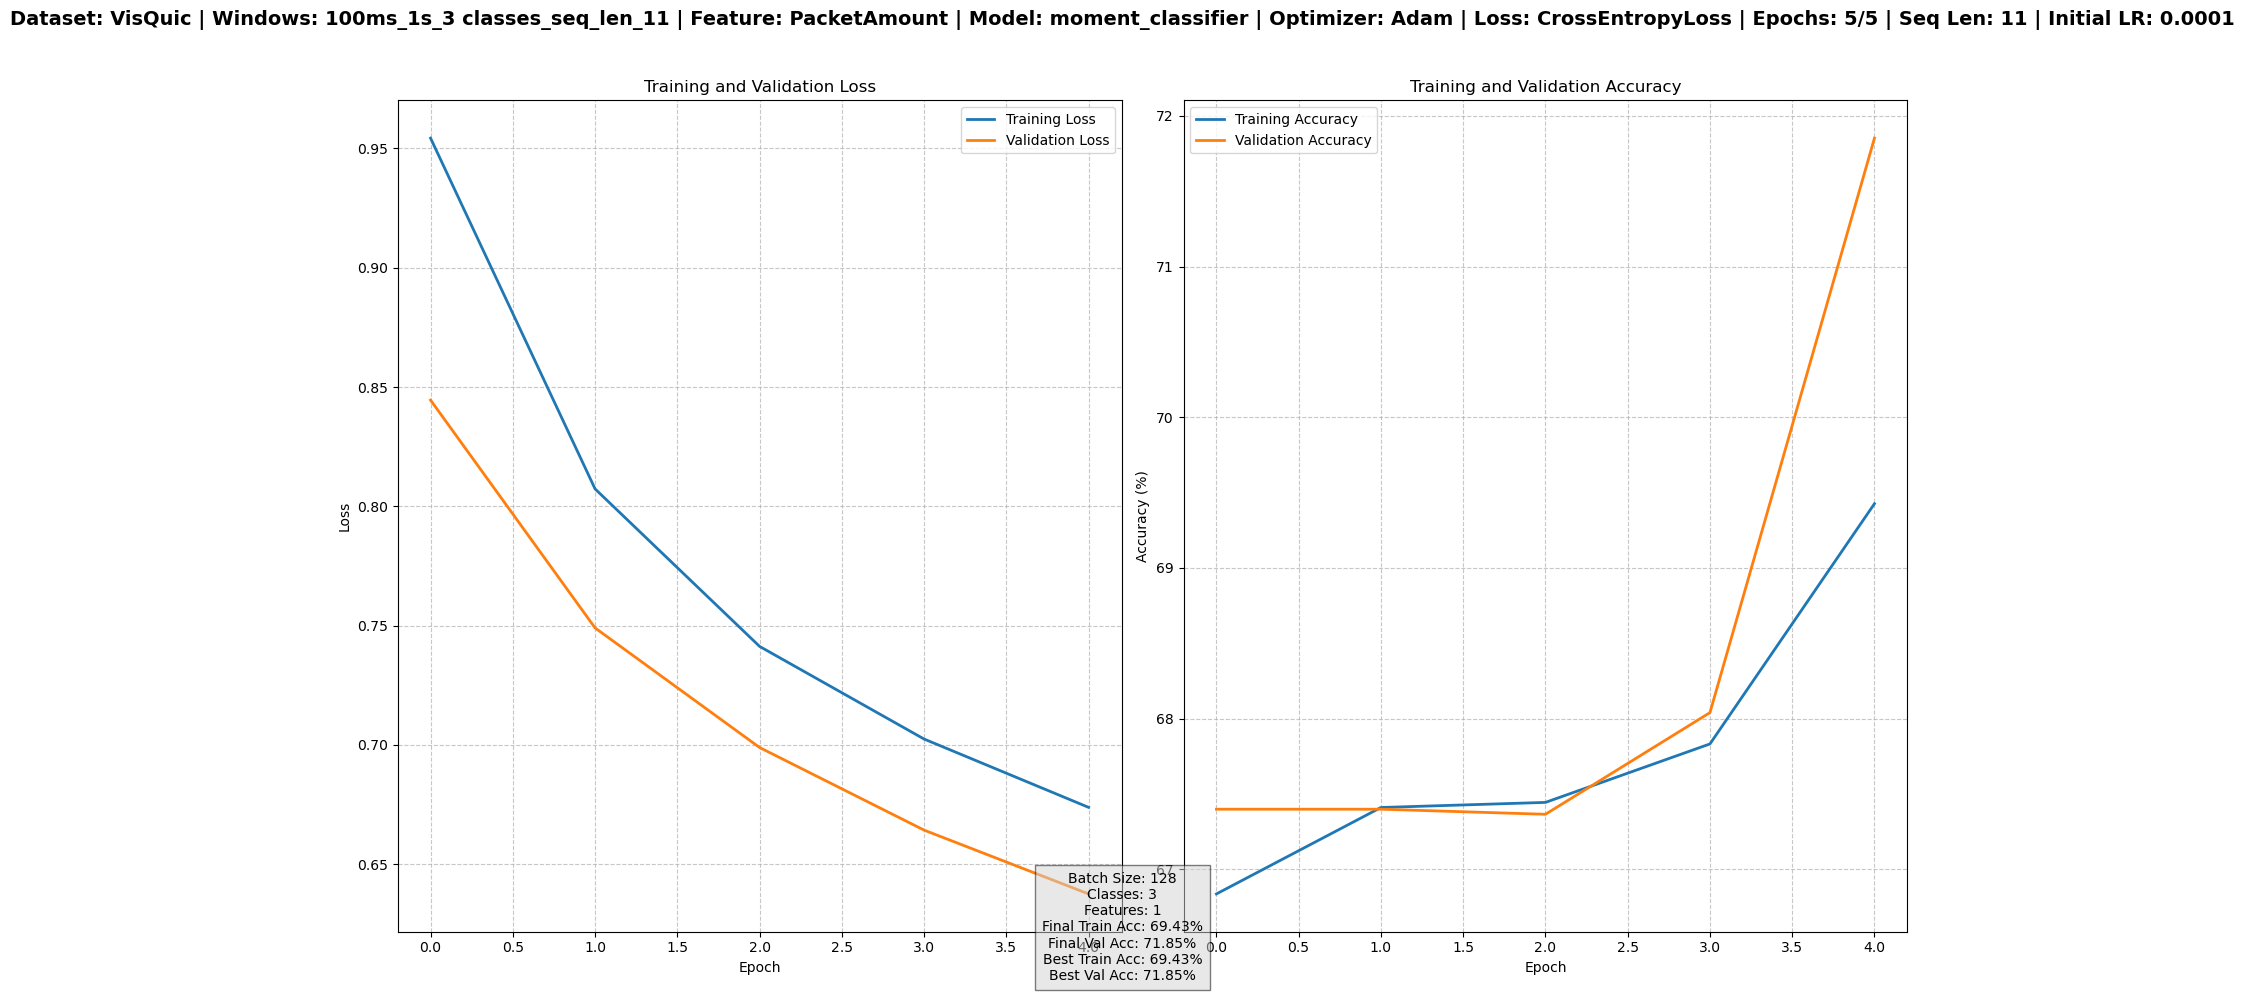


Classification Report:
              precision    recall  f1-score   support

  Google Doc       0.00      0.00      0.00       290
Google Drive       0.71      0.99      0.83      1997
     Youtube       0.80      0.21      0.34       676

    accuracy                           0.72      2963
   macro avg       0.50      0.40      0.39      2963
weighted avg       0.66      0.72      0.64      2963

Val Accuracy: 71.85%
Val Precision (Macro): 50.48%
Val Recall (Macro): 40.27%
Val F1 Score (Macro): 38.96%

Evaluation Complete!
Total evaluation time: 2490.68 ms

Results saved to: /home/chanan/Time-Series-Library/results/VisQuic/VisQuic_model_Adam_optimizer_CrossEntropyLoss_PacketAmount_20250415_091618_detailed.csv


/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/chanan/miniconda3/envs/moment/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [27]:
dataset_name="VisQuic"
small_window = ["100ms"]
big_window = ["1s"]
classes_count =["3 classes"]
pos = 2

model_types = ['moment']
feature_name='PacketAmount'

datasets_dic = prepare_datasets(dataset_name=dataset_name,
                                small_windows=small_window,
                                big_windows=big_window,
                                class_counts=classes_count,
                                pos=pos                
                                )

results = evaluate_models_on_datasets(datasets_dict=datasets_dic,
                                      model_types=model_types,
                                      dataset_name=dataset_name,
                                      use_class_weights=False,
                                      criterion_type='CrossEntropyLoss',
                                      optimizer_type='Adam',
                                      feature_name=feature_name
                                     )